# Forward

The basic structures and mathematics of life cycle assessment are quite simple, and you could write your own LCA system pretty easily - especially with the tools available today. In fact, that's a good first exercise - these notebooks are designed to work with a coding-focused LLM. See what it gives you for the prompt:

```
Can you write a simple Python script to calculate life cycle assessments? Don't look at any other files on this computer, just use the training knowledge you have already.
```

Writing your own system is the only real way to completely learn about how things actually work. So what's the point of using Brightway if you can roll your own? Brightway is a set of tools designed to work with the real world of LCA - real data sources, and real calculation optimizations. It is also flexible enough to fit into most workflows. You don't have to use Brightway or its friends, and it isn't always the right choice! But these notebooks will give you an introduction if you do choose to use it.

# 1 - The supply chain graph

This notebook describes how supply chain graphs can be entered, edited, and used in the latest version of the Brightway LCA framework. It follows our recommended practice for using Brightway. When in doubt on which commands to use, please [check the cheat sheet](https://docs.brightway.dev/en/latest/content/cheatsheet/index.html), and let us know if you think something there is missing.

The most common approach in life cycle assessment, and the approach that Brightway uses, is to model systems as [graphs](https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)). Graphs have nodes and edges, and data attributes can be attached to both nodes and edges. Here is an example of a graph for a simple product system making a bicycle and the associated LCA objects:

<img src="images/supply-chain-simple.png">

In our graph, edges are [directed](https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)#Directed_graph) - each edge has a _source_ and a _target_. 

We have also added types to both the nodes and edges. These types are metadata, just like things like names, units, and locations. This metadata helps us make sense of the graph in the context of LCA.

Brightway has a suggested set of labels to use for metadata for the different node and edge types - see the [Brightway interface schemas](https://github.com/brightway-lca/bw_interface_schemas/blob/main/bw_interface_schemas/models.py)

This graph can be logically divided between processes - things that do something, action words, or verbs, and products and elementary flows - the physical things being acted upon, or nouns:

<img src="images/bipartite.png">

Brightway is designed around flexibility, and so this partition is a convention, not a rule. However, for the sake of your and our sanity, we strongly recommend following this pattern :)

It can be helpful to split an LCA graph into a set of [subgraphs](https://en.wikipedia.org/wiki/Glossary_of_graph_theory#subgraph). For example, we might want to separate the work of two analysts, or separate a foreground and a background system. In Brightway, a subgraph is called a `Database`. Let's add a `Database to our graph:

<img src="images/with-database.png">

A `Database` is just a collection of nodes - it can be large or small, there aren't any general rules. Edges don't belong to a database, as they can cross from one database to another.

In Brightway, we currently have "graphy"-type methods to access nodes and edges, and non-"graphy"-type methods to access database relationships and LCIA, but you should be thinking of them mentally as being part of a large graph. Let's make that graph:

## Installation

Full installation instructions are at [docs.brightway.dev](https://docs.brightway.dev/en/latest/content/installation/index.html).

For this class, you need the following packages (all installable via `pip` or `conda`):

| Package | Purpose |
|---|---|
| `bw2data` | Graph database — nodes, edges, projects |
| `bw2calc` | Matrix construction and LCA calculation |
| `bw2io` | Import/export (Excel, ecospold, etc.) |
| `bw2analyzer` | Contribution analysis, recursive traversal, concentration metrics |
| `bw_graph_tools` | Structured supply-chain graph traversal (`Node`/`Edge`/`Flow`) |
| `bw_processing` | Low-level datapackage building (notebook 4) |
| `bw_eotw` | Dynamic / rich edges (notebook 5) |
| `stats_arrays` | Uncertainty distributions |
| `matrix_utils` | Sparse matrix utilities |
| `networkx` | Graph construction and visualisation (notebook 7) |
| `numpy`, `scipy`, `matplotlib`, `pandas`, `seaborn` | Numerics and plotting |
| `openpyxl` | Read/write Excel files (notebook 3) |

```bash
pip install bw2data bw2calc bw2io bw2analyzer bw_graph_tools bw_eotw networkx matplotlib seaborn openpyxl jupyterlab
```

## Using LLMs in this notebook

You are not expected to memorize Python syntax. Use Claude, ChatGPT, or GitHub Copilot freely to help you write code for the exercises. LLMs work well when you:
- Describe what you want in plain English, including library names (`bw2data`, `bw2calc`)
- Paste error messages directly — the LLM can usually diagnose them immediately
- Ask follow-up questions if the first answer doesn't work

Focus on understanding **what** you want to compute. Let the LLM help with the **how**.

In [1]:
import bw2data as bd

## Switching graphs — `projects`

A Brightway `project` is a separate graph — completely self-contained, and independent of other projects. This independence can lead to data duplication, but helps keep each project safe from the changes in the others.

<div class="alert alert-block alert-warning">
<b>Warning:</b> There isn't a great way to share data across projects. Instead, it's better to write reproducible data pipelines that can be shared.
</div>

We start in the `default` project:

In [2]:
bd.projects.current

'default'

We can change to a new project:

In [3]:
bd.projects.set_current("Another project")
bd.projects.current

'Another project'

We now don't have any databases or any other data in the graph:

In [4]:
bd.databases

Databases dictionary with 0 objects

Let's switch back to our default project. It isn't best practice to do data development in the `default` project, so let's rename it:

In [5]:
# Rename the current project; guard against running this cell twice
if 'Bicycle example' not in bd.projects:
    bd.projects.rename_project('Bicycle example')
else:
    bd.projects.delete_project('Another project', delete_dir=True)
    bd.projects.set_current('Bicycle example')
bd.projects.current

'Bicycle example'

During development, it is very convenient to just delete everything and rerun the notebook to get the right data. 

<div class="alert alert-success"><b>Key Principle:</b> In Brightway you should get used to creating reproducible workflows, and be comfortable regenerating your entire project. This means that you minimize or eliminate any manual steps.</div>

Let's make a shortcut to purge the project:

In [6]:
I_SCREWED_UP = True

if I_SCREWED_UP:
    try:
        bd.projects.delete_project("Bicycle example", delete_dir=True)
    except ValueError:
        pass

### Exercise 1: Explore your projects

List all projects currently registered in Brightway. How many projects exist? Then check which project is currently active. Try creating a third project called `"Sandbox"` and confirm it appears in the list.

<details><summary>Hint</summary>
Use <code>list(bd.projects)</code> to see all projects. Use <code>bd.projects.set_current("Sandbox")</code> to create and switch to a new project. Don't forget to switch back to <code>"Bicycle example"</code> when done.
</details>

In [7]:
# Your code here

Make sure we are in the right project before continuing:

In [8]:
bd.projects.set_current("Bicycle example")

## Databases

A `Database` is a named collection of nodes within the current project. Let's create and register one:

In [9]:
db = bd.Database("🚲")
# Let the metadata system know this database exists. Not necessary if using a `bw2io` importer.
db.register()

Registering a database allows us to find it in our registry of databases (sorry if that was a bit recursive!):

In [10]:
bd.databases

Databases dictionary with 1 object(s):
	🚲

Creating a `Database` also created its metadata:

In [11]:
db.metadata

{'depends': [],
 'backend': 'sqlite',
 'number': 0,
 'modified': '2026-04-27T08:56:11.459429',
 'geocollections': [],
 'processed': '2026-04-27T08:56:11.460094',
 'dirty': False}

### Exercise 2: Check your databases

Write a one-liner that prints how many databases are registered in the current project. Then check what keys are stored in `db.metadata` — what information does Brightway track automatically?

<details><summary>Hint</summary>
Use <code>len(bd.databases)</code> for the count. <code>db.metadata</code> is a plain dictionary — you can inspect its keys with <code>db.metadata.keys()</code>.
</details>

In [12]:
# Your code here

## Creating nodes

Our first two nodes — the bicycle itself, and the bicycle production activity.

We are using here some [fixed values for type labels](https://github.com/brightway-lca/brightway2-data/blob/main/bw2data/configuration.py). This is preferable to entering the strings ourselves to avoid human error or inconsistency.

<div class="alert alert-block alert-warning">
<b>Warning:</b> Brightway doesn't enforce node or edge types - it is up to you to build a sensible system.
</div>

In [13]:
bicycle = db.new_node(
    name="bicycle",
    unit="number",
    type=bd.labels.product_node_default,
)

bike_production = db.new_node(
    name="bike production",
    location="DK",
    type=bd.labels.process_node_default,
)

bicycle.save()
bike_production.save()

*Question* for reflection: Why does the bicycle production have a location and not a unit (and the opposite for the bicycle)?

*Question*: What other attributes like location could we add to bicycle production?

### Exercise 3: Add metadata to `bike_production`

Add a `comment` field to `bike_production` explaining what it does (e.g. `"Assembles a bicycle from carbon fibre parts in Denmark"`). Then save the node and confirm the comment was stored by reading it back.

<details><summary>Hint</summary>
Nodes act like dictionaries: <code>bike_production['comment'] = "your text"</code>. Don't forget to call <code>bike_production.save()</code> — unsaved changes are lost.
</details>

In [14]:
# Your code here

## Products and their reference processes

A **product node** (like `bicycle`) is a generic object — the bicycle as a concept, something you can buy, use, or model. It carries properties like name, unit, and categories.

But in LCA every product is normally *associated with* a **reference process** — the process that produces it. The process inherits the meaning of the product (what is being made, in what unit, in what context), and perhaps some chemical, physical, or economic properties associated with that process. When you search for a product in Brightway, you often navigate *via* its reference process.

This relationship is captured by:
- A **production edge** from the process to the product (with `type=bd.labels.production_edge_default` and `functional=True`)
- The `reference product` field on the process (the name of the product it produces). Note that this is a _convention_, not a requirement!

<div class="alert alert-block alert-info">
<b>Tip:</b> The <code>functional</code> tag tells the system whether or not we need to do allocation or some other approach to handling multifunctionality. However, this doesn't happen automatically - you can use the <code>multifunctional</code> library, or build your own system.
</div>

This matters for calculation: when Brightway builds the technosphere matrix, it maps **products (rows)** to their **producing processes (columns)**. Each product should have exactly one producing process so the matrix is square and non-singular.

<div class="alert alert-block alert-warning">
<b>Warning:</b> The net result of the reference process association is that products in the matrix <i>aren't</i> generic products - i.e. no longer a bicycle, but the specific bicycle produced by a specific process. The specificity of the product depends on the specificity of the process.
</div>

We can check the relationship with `.producers()`:

> **Note:** `.producers()` will be empty until we add production edges below. We will revisit this after creating the edges.

Let's add the rest of the life cycle inventory:

In [15]:
natural_gas = db.new_node(
    name='natural gas',
    unit='megajoule',
    type=bd.labels.product_node_default,
)
natural_gas_production = db.new_node(
    name='natural gas production',
    location='NO',
    type=bd.labels.process_node_default,
)

natural_gas.save()
natural_gas_production.save()

Brightway doesn't enforce any uniqueness constraints on fields like `name`. The only fields that must be unique are a combination of the `database` and the node `code`. 

<div class="alert alert-block alert-info">
<b>Tip:</b> You should probably make names unique within your databases - it makes searching and interpretation much easier.
</div>

If we can specify the `code` ourselves, we can run the same cell twice safely:

In [16]:
cf_production = db.new_node(
    code="cf-production",
    name='carbon fibre production',
    location='DE',
    type=bd.labels.process_node_default,
)
cf = db.new_node(
    code="cf",
    name='carbon fibre',
    unit="kilogram",
    type=bd.labels.product_node_default,
)


cf_production.save()
cf.save()

Brightway allows you complete flexibility to store any additional fields that you want on nodes and edges, but our recommendation is to use the following for fields outside the base set of fields given in [bw_interface_schemas](https://github.com/brightway-lca/bw_interface_schemas/blob/main/bw_interface_schemas/models.py):

* `documentation`
    * `dict[str, str]`, e.g. `node['documentation'] = {"treatment_standards_routes": "from processing of high-energy waste"}`
    * For documentation fields outside the general comment
* `tags`
    * `dict[str, JsonValue]`, e.g. `node['tags'] = {"CN 2024": "http://data.europa.eu/xsp/cn2024/681511000080", "start_year": 2024}`
    * For items which come a pre-defined and finite set of possible values
* `properties`
    * `dict[str, JsonValue]`, e.g. `node['properties'] = {"carbon_mass_fraction": 0.5}`
    * Quantitative measure of the process or product

<div class="alert alert-block alert-warning">
<b>Warning:</b> Be careful setting values like <code>node['tags'] = {<something>}</code> - this will overwrite any data that was already given as <code>tags</code>. If you aren't sure if <code>tags</code> exists, you can do <code>node.setdefault('tags', {})['<something>'] = '<something>'</code> (<a href="https://docs.python.org/3/library/stdtypes.html#dict.setdefault">setdefault documentation</a>).
</div> 

In [17]:
co2 = db.new_node(
    name="Carbon Dioxide", 
    categories=('air',),
    tags={'CAS Number': '124-38-9'},
    unit='kilogram',
    type=bd.labels.biosphere_node_default,
)

co2.save()

### Exercise 4: Add a tag to the CO2 node

Add a second tag to the `co2` node recording its molecular weight: key `'molecular_weight_g_mol'`, value `44`. Use `setdefault` so you don't accidentally overwrite the existing `'CAS Number'` tag. Save the node and verify both tags are present.

<details><summary>Hint</summary>
<code>co2.setdefault('tags', {})['molecular_weight_g_mol'] = 44</code> then <code>co2.save()</code>. Check with <code>co2['tags']</code>.
</details>

In [18]:
# Your code here

## Adding edges

We also need to create edges between the nodes. We can do this in many ways, here is one - let's add the production of products by processes:

In [19]:
bike_production.new_edge(
    amount=1,
    input=bicycle,
    type=bd.labels.production_edge_default,
    functional=True,
).save()
cf_production.new_edge(
    amount=1,
    input=cf,
    type=bd.labels.production_edge_default,
    functional=True,
).save()
natural_gas_production.new_edge(
    amount=1,
    input=natural_gas,
    type=bd.labels.production_edge_default,
    functional=True,
).save()    

Now that we have production edges, we can confirm the product-process relationship:

In [20]:
# Show which process produces the bicycle
print("Producers of bicycle:", list(bicycle.producers()))

# The production edge carries functional=True to mark it as the reference production
for edge in bicycle.producers():
    print("  Edge functional flag:", edge.get('functional'))
    print("  Producing process:", edge['output'])

Producers of bicycle: []


The use of `input` is a bit weird in the above - this will change as it is incorrect.

Sometimes we can run the same cell multiple times, and create duplicate exchanges. Brightway **will allow** you to create multiple edges between the same source and target.

*Question* for reflection: Why does Brightway allow such seemingly duplicate edges? Does this reflect real-world conditions?

Brightway has a utility function to fix these errors:

In [21]:
db.delete_duplicate_exchanges()

### Exercise 5: Count technosphere edges

Run the production edge cell above a second time to create duplicate edges, then call `db.delete_duplicate_exchanges()`. Before deleting, write a one-liner using a list comprehension to count how many production edges `bike_production` currently has.

<details><summary>Hint</summary>
<code>len([e for e in bike_production.exchanges() if e['type'] == bd.labels.production_edge_default])</code>. After deduplication, there should be exactly one.
</details>

In [22]:
# Your code here

Now let's add the material and energy inputs:

In [23]:
bike_production.new_edge(
    amount=2.5, 
    type=bd.labels.consumption_edge_default,
    input=cf
).save()

What about some uncertainty? We use [stats_arrays](https://stats-arrays.readthedocs.io/en/latest/) to model probability distribution functions.

In [24]:
cf_production.new_edge(
    amount=237.3,  # plus 58 kWh of electricity, in ecoinvent 3.8 
    uncertainty_type=5, 
    minimum=200, 
    maximum=300, 
    type=bd.labels.consumption_edge_default,
    input=natural_gas,
).save()

And our emission of carbon dioxide:

In [25]:
cf_production.new_edge(
    amount=26.6, 
    uncertainty_type=5, 
    minimum=26,
    maximum=27.2, 
    type=bd.labels.biosphere_edge_default,
    input=co2,
).save()

## Exchange iterators

We have shortcuts to traverse the supply chain graph. For inputs, we have `.technosphere()` and `.biosphere()`; for producing edges, we have `.producers()`, and for edges to other nodes which consume the outputs of our node there is `.consumers()`. You can also get all edges with `.edges()`.

These are all [iterators](https://jakevdp.github.io/WhirlwindTourOfPython/10-iterators.html).

In [26]:
list(cf_production.technosphere())

[Exchange: 237.3 megajoule 'natural gas' (megajoule, GLO, None) to 'carbon fibre production' (None, DE, None)]

In [27]:
list(cf_production.biosphere())

[Exchange: 26.6 kilogram 'Carbon Dioxide' (kilogram, GLO, ('air',)) to 'carbon fibre production' (None, DE, None)]

In [28]:
list(cf.consumers())

[Exchange: 2.5 kilogram 'carbon fibre' (kilogram, GLO, None) to 'bike production' (None, DK, None)]

In [29]:
list(cf_production.producers())

[Exchange: 1 kilogram 'carbon fibre' (kilogram, GLO, None) from 'carbon fibre production' (None, DE, None)]

### Exercise 6: Technosphere edge count for `bike_production`

Using a list comprehension, count how many **technosphere** (consumption) edges `bike_production` has. Then print the name and amount of each input.

<details><summary>Hint</summary>
<code>list(bike_production.technosphere())</code> returns all consumption edges. Each edge <code>e</code> has <code>e['amount']</code> and <code>e.input['name']</code>.
</details>

In [30]:
# Your code here

## The linearization problem — a preview

In the graph model, a product can *in principle* have multiple producers. Let's demonstrate this by creating a second process that also produces the `bicycle` product:

In [31]:
# Create a second (hypothetical) producer of the bicycle
bike_production_2 = db.new_node(
    code="bike-production-2",
    name="bike production (aluminium)",
    location="CN",
    type=bd.labels.process_node_default,
)
bike_production_2.save()

bike_production_2.new_edge(
    amount=1,
    input=bicycle,
    type=bd.labels.production_edge_default,
    functional=True,
).save()

print("Producers of bicycle:", [list(e['output']) for e in bicycle.producers()])

Producers of bicycle: []


Now `bicycle` has **two producers**. This is valid in a graph — real supply chains do have competing suppliers. But it creates a problem:

> **When Brightway builds the technosphere matrix, which producer does it choose?**

The quick answer is that it doesn't - Brightway will happily let you build unsolvable systems. It even has a nonsquare A matrix optimization solver, because sometimes that's what you want.

<div class="alert alert-block alert-warning">
<b>Warning:</b> It is up to you to build a sensible system.
</div>

Let's clean up by deleting the second producer:

In [32]:
bike_production_2.delete()

# Confirm only one producer remains
print("Producers of bicycle after cleanup:", list(bicycle.producers()))

Producers of bicycle after cleanup: []


We will return to this constraint in **notebook 3 (Building and using matrices in bw2calc)** when we see exactly how the technosphere matrix is assembled, and in notebook 5 (Dynamic Graphs) where we explore ways to relax it.

## A quick LCA calculation preview

This is a life cycle inventory, and is enough to do an LCI calculation. Let's do a quick calculation:

In [33]:
import bw2calc as bc

Don't worry about the syntax here right now, we will talk about it later.

In [34]:
bd.projects.set_current("Bicycle example")
functional_unit, data_objs, _ = bd.prepare_lca_inputs({bicycle: 1}, remapping=False)

In [35]:
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()

*Question*: How much CO2 should be emitted by our functional unit? You can do this calculation by examining the graph manually.

In [36]:
lca.inventory[lca.dicts.biosphere[co2.id], :].sum()

np.float64(66.5000009536743)

### Exercise 8: Recalculate with a different carbon fibre amount

Find the consumption edge between `bike_production` and `cf`, change the amount to `3` kg (instead of 2.5 kg), save the edge, and rerun the LCA. What is the new total CO2 emission? (Tip: you will need to rebuild the LCA object from scratch to pick up the change.)

<details><summary>Hint</summary>
Use <code>list(bike_production.technosphere())</code> to find the edge. Set <code>edge['amount'] = 3</code> and <code>edge.save()</code>. Then re-run from <code>bd.prepare_lca_inputs</code> onward.
</details>

In [37]:
# Your code here

Finally, if we want to do impact assessment, we need some nodes to represent impact categories, and edges to represent characterization factors:

<img src="images/with-lcia.png">

## LCIA

To define characterization nodes and edges, we use a different data structure:

In [38]:
import stats_arrays as sa

In [39]:
ipcc = bd.Method(('IPCC',))
ipcc.write([
    (co2, {'amount': 1, 'uncertainty_type': sa.NormalUncertainty.id, 'loc': 1, 'scale': 0.05}),
])

We can now do a full LCIA, not just an LCI:

In [40]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs({bicycle: 1}, method=('IPCC',), remapping=False)

In [41]:
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()
lca.lcia()
lca.score

66.5000009536743

To use uncertainty, we tell the `LCA` object to use the probability distributions:

In [42]:
import pandas as pd

array([[<Axes: title={'center': 'score'}>]], dtype=object)

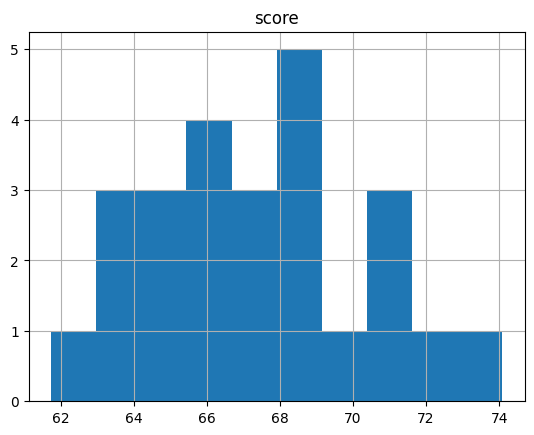

In [43]:
lca = bc.LCA(demand=functional_unit, data_objs=data_objs, use_distributions=True)
lca.lci()
lca.lcia()

df = pd.DataFrame([{'score': lca.score} for _ in zip(lca, range(25))])
df.hist()

### Exercise 9: Create a new impact category

Create a new LCIA method called `('Resource Depletion', 'Natural Gas')` with a characterization factor of `1` for `natural_gas` (no uncertainty). Calculate the LCIA score for producing 1 bicycle. What value do you expect, and does the result match?

<details><summary>Hint</summary>
Use <code>bd.Method(('Resource Depletion', 'Natural Gas'))</code> and <code>.write([(natural_gas, {'amount': 1})])</code>. Then prepare LCA inputs with <code>method=('Resource Depletion', 'Natural Gas')</code> and run <code>lca.lci(); lca.lcia(); lca.score</code>.
</details>

In [44]:
# Your code here

## Exercise: Build a steel bicycle

Create a new bicycle made of steel. You will need some coal and some iron ore mining for the steel, and some steel for the bicycle.

Your use of steel consumed some iron ore, a natural resource. In a **new database**, create a biosphere flow for this iron ore, and add the iron ore flow. You might not be sure about the numbers - you can reflect that in the uncertainty you assign to the exchanges.

In [45]:
# Your code here

## Exercise: LCIA for iron ore

Create a new LCIA method for your iron ore consumption. Calculate the LCIA result you should get, and then verify that you have the correct value.

In [46]:
# Your code here

## Searching through the database

Let's explore **BAFU-2025-v2**, the Swiss Federal Office for the Environment life cycle inventory — a freely available database with over 11,000 processes covering the Swiss background system. We switch to the project where it is already installed:

In [47]:
bd.projects.set_current('BAFU 2025 v2')
db = bd.Database('BAFU-2025-v2')
print(f'Database: {db.name}, {len(db)} nodes')

Database: BAFU-2025-v2, 11747 nodes


In [48]:
db.search('solar panel')

['Photovoltaic panel, single-Si, Vogelsang-Kioto Solar, at plant' (square meter, AT, ['photovoltaic', 'production of components']),
 'Photovoltaic panel, single-Si, Kioto Solar PVP-GExxxM, at plant' (square meter, AT, ['photovoltaic', 'production of components']),
 'Photovoltaic panel, micro-Si, at regional storage' (square meter, RER, ['chemicals', 'processing']),
 'Photovoltaic panel, micro-Si, at plant' (square meter, CN, ['chemicals', 'processing']),
 'xxx Photovoltaic panel, mc-Si, at plant' (unit, RER, ['material, obsolete', 'others, obsolete']),
 'xxx Photovoltaic panel, pc-Si, at plant' (unit, RER, ['material, obsolete', 'others, obsolete']),
 'Photovoltaic panel, single-Si, at plant' (square meter, RER, ['photovoltaic', 'production of components']),
 'Photovoltaic panel, multi-Si, at plant' (square meter, RER, ['photovoltaic', 'production of components']),
 'Photovoltaic panel, single-Si, at plant' (square meter, US, ['photovoltaic', 'production of components']),
 'Photovoltai

BAFU (like most ecospold2-based databases) uses a single node type called `processwithreferenceproduct` — each node is a process that produces exactly one reference product. This is different from the graph we built manually, where we created separate `process` and `product` nodes.

In [49]:
{node['type'] for node in db}

{'processwithreferenceproduct'}

### Exercise 10: Search and count

Search for `'transport lorry'` in the BAFU database. How many results are there? Print the name and location of each.

<details><summary>Hint</summary>
Use <code>results = db.search('transport lorry')</code>, then loop or use a list comprehension.
</details>

In [50]:
# Your code here

We can also retrieve a specific node by its exact attributes using `bd.get_node()`:

In [51]:
lorry = bd.get_node(
    database='BAFU-2025-v2',
    name='Transport, freight, lorry, diesel, 18t gross weight, fleet average, long haul',
)
lorry['location'], lorry['unit']

('CH', 'ton kilometer')

### Exercise 11: Graph traversal in BAFU

Using the lorry node above, call `.technosphere()` to list its inputs. How many technosphere inputs does it have? Print the name and amount of each.

<details><summary>Hint</summary>
Use <code>list(lorry.technosphere())</code> and access <code>exc['amount']</code> and <code>exc.input['name']</code> for each exchange.
</details>

In [52]:
# Your code here

Switch back to the bicycle project for the exchange iterators section:

In [54]:
bd.projects.set_current('Bicycle example')